In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def safe_read_series(path: str, column: str, index: pd.Index) -> pd.Series:
    """
    Load a single column from a CSV if it exists.
    Returns a Series indexed by the provided `index` (typically test IDs).
    """
    if os.path.isfile(path):
        df = pd.read_csv(path)
        if column in df.columns:
            if "id" in df.columns:
                return df.set_index("id")[column].reindex(index)
            else:
                return pd.Series(df[column].values, index=index, name=column)
    return pd.Series(np.nan, index=index, name=column)




In [2]:
train_path = "../input/champs-scalar-coupling/train.csv"
test_path = "../input/champs-scalar-coupling/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

test.set_index("id", inplace=True)

TARGET = "scalar_coupling_constant"
overall_mean = train[TARGET].mean()
type_mean = train.groupby("type")[TARGET].mean()
type_median = train.groupby("type")[TARGET].median()

target_min = train[TARGET].min()
target_max = train[TARGET].max()




In [3]:
test["n1"] = safe_read_series(
    "../input/champ-preds/gnn_median_2302.csv", TARGET, test.index
)
test["n2"] = safe_read_series(
    "../input/champ-preds/gnn0_median_2068.csv", TARGET, test.index
)


def get_median_from_files(files):
    series_list = []
    for f in files:
        if os.path.isfile(f):
            df = pd.read_csv(f, index_col=0)
            series = pd.Series(df[TARGET].values, index=test.index, name="pred")
            series_list.append(series)
    if not series_list:
        return pd.Series(np.nan, index=test.index, name="median")
    concat_sub = pd.concat(series_list, axis=1, sort=True)
    return concat_sub.median(axis=1)


test["lgb_a"] = get_median_from_files(
    [
        "../input/champ-preds/submission_type_2100.csv",
        "../input/champ-preds/submission_type_2085.csv",
    ]
)
test["lgb_m"] = get_median_from_files(
    [
        "../input/champ-preds/lgb_type_full_f286_10.csv",
        "../input/champ-preds/lgb_type_full_f262_10.csv",
    ]
)
test["nnet"] = get_median_from_files(
    [
        "../input/nn-seed-10/nnet_sub.csv",
        "../input/nn-seed-11/nnet_sub.csv",
        "../input/nnet-c-seed-10/lgb_type_cv-1.7126_mae0.23572_fd5_10.csv",
        "../input/nnet-c-seed-11/lgb_type_cv-1.70994_mae0.23497_fd5_11.csv",
        "../input/nnet-c-seed-12/lgb_type_cv-1.71029_mae0.23523_fd5_12.csv",
        "../input/nnet-b-seed-10/lgb_type_cv-1.72296_mae0.24019_bags-1_f120_fd5_10.csv",
        "../input/nnet-b-seed-11/lgb_type_cv-1.70647_mae0.2376_bags-1_f120_fd5_11.csv",
        "../input/nnet-b-seed-12/lgb_type_cv-1.69833_mae0.24106_bags-1_f120_fd5_12.csv",
        "../input/nnet-try-seed-11/lgb_type_cv-1.64944_mae0.23965_bags-1_f120_fd5_11.csv",
    ]
)
test["lb"] = safe_read_series(
    "../input/chemistry-of-best-models-1-839/stack_median.csv", TARGET, test.index
)




/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


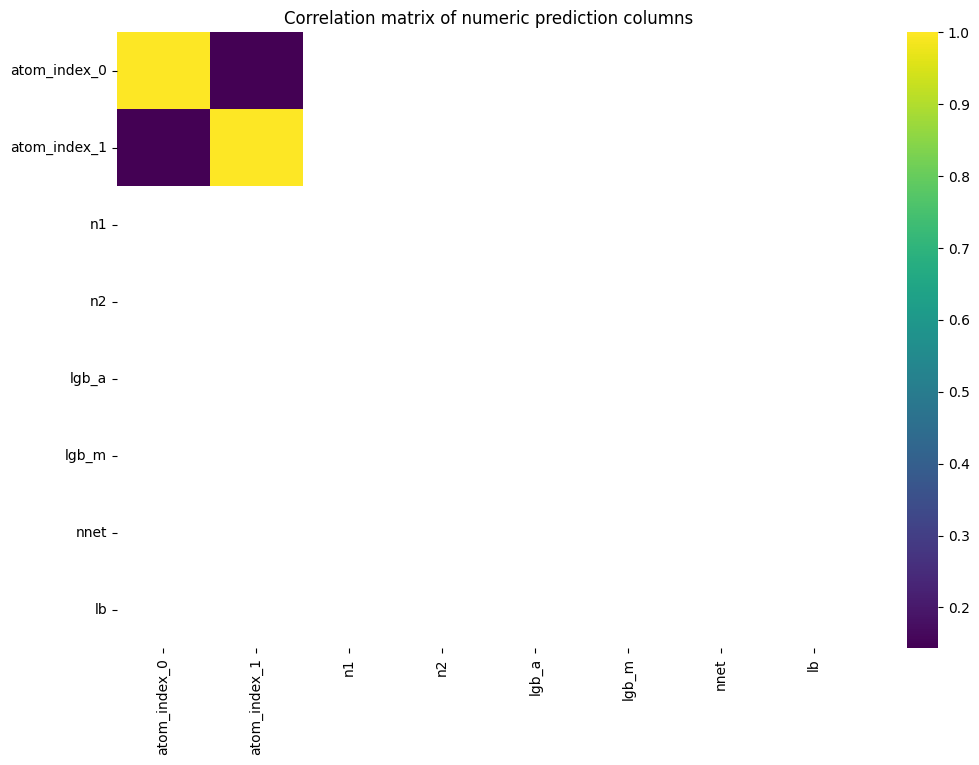

In [4]:
numeric_cols = test.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    corr = test[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=False, cmap="viridis")
    plt.title("Correlation matrix of numeric prediction columns")
    plt.show()




In [5]:
# Ensure all expected prediction columns exist
pred_cols = ["n1", "n2", "lgb_a", "lgb_m", "nnet", "lb"]
for col in pred_cols:
    if col not in test.columns:
        test[col] = np.nan

# Row‑wise median of available model predictions
median_pred = test[pred_cols].median(axis=1, skipna=True)

# Use per‑type **mean** as a robust baseline fallback
type_fallback = test["type"].map(type_mean).fillna(overall_mean)

# Blend: give more weight to the ensemble median (0.7) and less to the baseline (0.3)
final = 0.7 * median_pred + 0.3 * type_fallback

# Fill any remaining NaNs with the overall training mean
final = final.fillna(overall_mean)

# Clip predictions to the observed target range to avoid extreme out‑of‑range values
final = final.clip(lower=target_min, upper=target_max)

test["final_preds"] = final




In [6]:
submission = pd.DataFrame(
    {"id": test.index, "scalar_coupling_constant": test["final_preds"].values}
)
submission_path = "ensemble_sub.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission written to {submission_path}")




Submission written to ensemble_sub.csv


In [7]:
submission.head(20)

,id,scalar_coupling_constant
0,2324604,15.916068
1,2324605,15.916068
2,2324606,15.916068
3,2324607,15.916068
4,2324608,15.916068
5,2324609,15.916068
6,2324610,15.916068
7,2324611,15.916068
8,2324612,15.916068
9,2324613,15.916068
